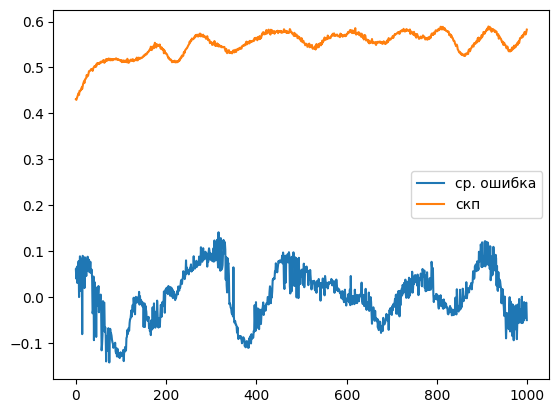

In [ ]:
# загрузка и нарезка
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

train_y = pd.read_csv('./final_project/train.csv', header=None).values
train_u = pd.read_csv('./final_project/etalon_for_train.csv', header=None).values
test_y = pd.read_csv('./final_project/test.csv', header=None).values
test_u = pd.read_csv('./final_project/etalon_for_test.csv', header=None).values

x_tr = torch.tensor(train_y[:, :4000], dtype=torch.float32).unsqueeze(1)
y_tr = torch.tensor(train_u[:, 4000:], dtype=torch.float32)
x_te = torch.tensor(test_y[:, :4000], dtype=torch.float32).unsqueeze(1)
y_te = test_u[:, 4000:]

loader = DataLoader(TensorDataset(x_tr, y_tr), batch_size=32, shuffle=True)

# сетка
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 5)
        self.conv2 = nn.Conv1d(16, 8, 5)
        self.fc = nn.Linear(8 * 3992, 1000) # 4000 - 4 - 4 = 3992

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = Net()
opt = optim.Adam(model.parameters())
crit = nn.MSELoss()

# трейн
model.train()
for ep in range(5):
    for bx, by in loader:
        opt.zero_grad()
        loss = crit(model(bx), by)
        loss.backward()
        opt.step()

# предикт и метрики
model.eval()
with torch.no_grad():
    preds = model(x_te).numpy()

delta_u = np.mean(preds - y_te, axis=0)
L = len(preds)
rms = np.sqrt(np.sum((preds - y_te - delta_u)**2, axis=0) / (L - 1))

# рисуем
plt.plot(delta_u, label='ср. ошибка')
plt.plot(rms, label='скп')
plt.legend()
plt.show()